In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
import joblib
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style("whitegrid")

print("✓ Imports successful")

✓ Imports successful


In [15]:
# ============================================
# CELL 2: Load Data - CICIDS2017 Wednesday File
# ============================================

from pathlib import Path

# Use Wednesday file - has multiple DoS attack types
data_path = Path('../data/raw/Wednesday-workingHours.pcap_ISCX.csv')

print(f"Loading data from: {data_path}")
df = pd.read_csv(data_path)

print(f"✓ Data loaded: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Check labels immediately
label_col = ' Label'
print("\nLabel distribution in loaded data:")
label_counts = df[label_col].value_counts()
print(label_counts)

# Verify we have both BENIGN and attacks
benign_count = (df[label_col] == 'BENIGN').sum()
attack_count = len(df) - benign_count

print(f"\n✓ BENIGN samples: {benign_count:,} ({benign_count/len(df)*100:.1f}%)")
print(f"✓ ATTACK samples: {attack_count:,} ({attack_count/len(df)*100:.1f}%)")

if attack_count == 0:
    print("\n❌ ERROR: No attack samples in this file!")
    raise ValueError("File contains only BENIGN samples")
else:
    print("✓ Dataset ready - contains both classes")

print("\nFirst few rows:")
display(df.head())

Loading data from: ..\data\raw\Wednesday-workingHours.pcap_ISCX.csv
✓ Data loaded: (692703, 79)
Memory usage: 454.44 MB

Label distribution in loaded data:
 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64

✓ BENIGN samples: 440,031 (63.5%)
✓ ATTACK samples: 252,672 (36.5%)
✓ Dataset ready - contains both classes

First few rows:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


DATA QUALITY ASSESSMENT

1. Data Types:
int64      54
float64    24
object      1
Name: count, dtype: int64

2. Missing Values:
Flow Bytes/s    1008
dtype: int64

3. Duplicate rows: 81909

4. Checking for infinity values...
⚠️  Found 1586 infinity values in 2 columns
   Flow Bytes/s: 289
    Flow Packets/s: 1297

5. Label Distribution:
 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


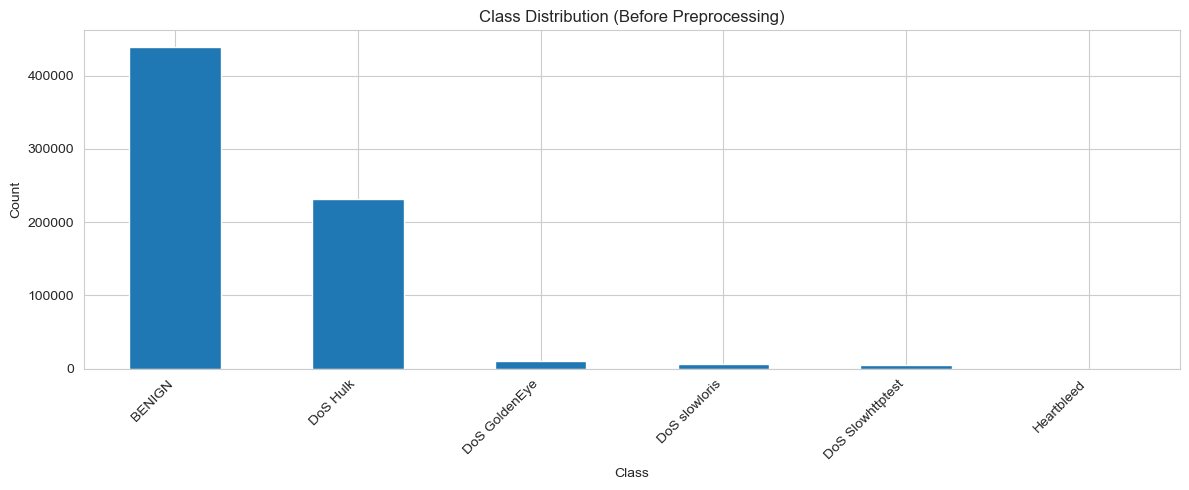

In [16]:
print("="*60)
print("DATA QUALITY ASSESSMENT")
print("="*60)

# 1. Check data types
print("\n1. Data Types:")
print(df.dtypes.value_counts())

# 2. Missing values
print("\n2. Missing Values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("✓ No missing values")

# 3. Duplicate rows
duplicates = df.duplicated().sum()
print(f"\n3. Duplicate rows: {duplicates}")

# 4. Check for infinity values (CICIDS2017 specific)
print("\n4. Checking for infinity values...")
inf_count = 0
inf_cols = []

for col in df.select_dtypes(include=[np.number]).columns:
    if np.isinf(df[col]).any():
        count = np.isinf(df[col]).sum()
        inf_count += count
        inf_cols.append((col, count))
        
if inf_count > 0:
    print(f"⚠️  Found {inf_count} infinity values in {len(inf_cols)} columns")
    for col, count in inf_cols[:5]:  # Show first 5
        print(f"   {col}: {count}")
else:
    print("✓ No infinity values")

# 5. Label distribution
print("\n5. Label Distribution:")
# Handle both NSL-KDD and CICIDS2017 label formats
label_col = 'label' if 'label' in df.columns else ' Label'
print(df[label_col].value_counts())

# Visualize
plt.figure(figsize=(12, 5))
df[label_col].value_counts().plot(kind='bar')
plt.title('Class Distribution (Before Preprocessing)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
print("\n" + "="*60)
print("STEP 1: HANDLING MISSING VALUES")
print("="*60)

# Check for missing values
missing_before = df.isnull().sum().sum()
print(f"Missing values before: {missing_before}")

if missing_before > 0:
    # Option 1: Drop rows with any missing values (if < 5%)
    missing_pct = (missing_before / df.size) * 100
    
    if missing_pct < 5:
        df = df.dropna()
        print(f"✓ Dropped rows with missing values ({missing_pct:.2f}% of data)")
    else:
        # Option 2: Impute with median for numerical columns
        numerical_cols = df.select_dtypes(include=[np.number]).columns
        for col in numerical_cols:
            if df[col].isnull().any():
                median_val = df[col].median()
                df[col].fillna(median_val, inplace=True)
                print(f"✓ Filled {col} with median: {median_val:.2f}")

missing_after = df.isnull().sum().sum()
print(f"Missing values after: {missing_after}")
print(f"Shape after cleaning: {df.shape}")


STEP 1: HANDLING MISSING VALUES
Missing values before: 1008
✓ Dropped rows with missing values (0.00% of data)
Missing values after: 0
Shape after cleaning: (691695, 79)


In [18]:
print("\n" + "="*60)
print("STEP 2: HANDLING INFINITY VALUES")
print("="*60)

# Replace infinity with NaN, then with large values
numerical_cols = df.select_dtypes(include=[np.number]).columns

inf_replacements = 0
for col in numerical_cols:
    if np.isinf(df[col]).any():
        # Replace +inf with max finite value * 1.5
        # Replace -inf with min finite value * 1.5
        finite_values = df[col][np.isfinite(df[col])]
        
        if len(finite_values) > 0:
            max_val = finite_values.max()
            min_val = finite_values.min()
            
            df[col].replace([np.inf], max_val * 1.5, inplace=True)
            df[col].replace([-np.inf], min_val * 1.5, inplace=True)
            inf_replacements += 1

print(f"✓ Replaced infinity values in {inf_replacements} columns")

# Verify no infinities remain
remaining_inf = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
print(f"Remaining infinity values: {remaining_inf}")


STEP 2: HANDLING INFINITY VALUES
✓ Replaced infinity values in 2 columns
Remaining infinity values: 0


In [19]:
print("\n" + "="*60)
print("STEP 3: REMOVING DUPLICATES")
print("="*60)

before_dup = len(df)
df = df.drop_duplicates()
after_dup = len(df)
removed = before_dup - after_dup

print(f"Rows before: {before_dup:,}")
print(f"Rows after: {after_dup:,}")
print(f"✓ Removed {removed:,} duplicate rows ({removed/before_dup*100:.2f}%)")


STEP 3: REMOVING DUPLICATES
Rows before: 691,695
Rows after: 610,733
✓ Removed 80,962 duplicate rows (11.70%)


In [20]:
# ============================================
# CELL 7: Encode Labels - CICIDS2017 (CORRECTED)
# ============================================

print("\n" + "="*60)
print("STEP 4: LABEL ENCODING (CICIDS2017)")
print("="*60)

# CICIDS2017 uses ' Label' (with space at beginning!)
label_col = ' Label'

# Verify column exists
if label_col not in df.columns:
    print("❌ Column ' Label' not found!")
    print("Available columns with 'label':", [c for c in df.columns if 'label' in c.lower()])
    raise ValueError("Label column not found")

print(f"✓ Using label column: '{label_col}'")

# Show original labels
print("\nOriginal label distribution:")
label_counts = df[label_col].value_counts()
print(label_counts)

# CICIDS2017 encoding function
def encode_binary_cicids(label):
    """
    CICIDS2017 binary encoding
    0 = BENIGN
    1 = Any attack type
    
    Note: Labels can be mixed case (DDoS, DoS, BENIGN, etc.)
    """
    # Convert to string, strip whitespace, convert to uppercase
    label_str = str(label).strip().upper()
    
    # Check if BENIGN (case-insensitive)
    if label_str == 'BENIGN':
        return 0  # BENIGN
    else:
        return 1  # ATTACK (DDoS, DoS, PortScan, etc.)

# Apply encoding
print("\n🔄 Applying binary encoding...")
df['Label_Binary'] = df[label_col].apply(encode_binary_cicids)

# Verify encoding worked
print("\n🔍 Encoding verification:")
print("\nOriginal → Encoded mapping:")
for original_label in sorted(df[label_col].unique()):
    encoded = encode_binary_cicids(original_label)
    label_name = "BENIGN" if encoded == 0 else "ATTACK"
    count = (df[label_col] == original_label).sum()
    pct = count / len(df) * 100
    print(f"  '{original_label}' → {encoded} ({label_name})")
    print(f"      Count: {count:,} ({pct:.1f}%)")

# Count final distribution
benign_count = (df['Label_Binary'] == 0).sum()
attack_count = (df['Label_Binary'] == 1).sum()
total = len(df)

print("\n" + "="*60)
print("FINAL BINARY ENCODING RESULT:")
print("="*60)
print(f"  0 = BENIGN: {benign_count:,} ({benign_count/total*100:.1f}%)")
print(f"  1 = ATTACK: {attack_count:,} ({attack_count/total*100:.1f}%)")
print(f"  Total: {total:,}")

# Critical sanity checks
if benign_count == 0:
    print("\n❌ ERROR: No BENIGN samples found!")
    print("Something is wrong with the encoding logic")
    print("Sample labels:", df[label_col].head(10).tolist())
    raise ValueError("Label encoding failed - no benign samples")

if attack_count == 0:
    print("\n❌ ERROR: No ATTACK samples found!")
    print("All samples are being classified as BENIGN")
    print("Sample labels:", df[label_col].head(10).tolist())
    raise ValueError("Label encoding failed - no attack samples")

# Both classes present
print("\n✅ SUCCESS: Both classes present - encoding successful!")

# Calculate class imbalance
imbalance_ratio = max(benign_count, attack_count) / min(benign_count, attack_count)
print(f"Class imbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 2:
    print("⚠️  Note: Moderate class imbalance detected")
    print("   We'll handle this with SMOTE during model training")
else:
    print("✓ Classes are reasonably balanced")

# Save original labels for reference
df['Label_Original'] = df[label_col]

print("\n✓ Label encoding complete!")



STEP 4: LABEL ENCODING (CICIDS2017)
✓ Using label column: ' Label'

Original label distribution:
 Label
BENIGN              416977
DoS Hulk            172846
DoS GoldenEye        10286
DoS slowloris         5385
DoS Slowhttptest      5228
Heartbleed              11
Name: count, dtype: int64

🔄 Applying binary encoding...

🔍 Encoding verification:

Original → Encoded mapping:
  'BENIGN' → 0 (BENIGN)
      Count: 416,977 (68.3%)
  'DoS GoldenEye' → 1 (ATTACK)
      Count: 10,286 (1.7%)
  'DoS Hulk' → 1 (ATTACK)
      Count: 172,846 (28.3%)
  'DoS Slowhttptest' → 1 (ATTACK)
      Count: 5,228 (0.9%)
  'DoS slowloris' → 1 (ATTACK)
      Count: 5,385 (0.9%)
  'Heartbleed' → 1 (ATTACK)
      Count: 11 (0.0%)

FINAL BINARY ENCODING RESULT:
  0 = BENIGN: 416,977 (68.3%)
  1 = ATTACK: 193,756 (31.7%)
  Total: 610,733

✅ SUCCESS: Both classes present - encoding successful!
Class imbalance ratio: 2.15:1
⚠️  Note: Moderate class imbalance detected
   We'll handle this with SMOTE during model trai

In [21]:
print("\n" + "="*60)
print("STEP 5: ENCODING CATEGORICAL FEATURES")
print("="*60)

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove label columns from categorical list
categorical_cols = [col for col in categorical_cols 
                   if col not in [label_col, 'Label_Binary', 'Label_Original']]

print(f"Found {len(categorical_cols)} categorical columns:")
for col in categorical_cols:
    unique_vals = df[col].nunique()
    print(f"  {col}: {unique_vals} unique values")

# Encode categorical columns
if len(categorical_cols) > 0:
    label_encoders = {}
    
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
        print(f"✓ Encoded {col}")
    
    # Save encoders
    joblib.dump(label_encoders, '../data/processed/label_encoders.pkl')
    print(f"\n✓ Saved label encoders")
else:
    print("✓ No categorical columns to encode")



STEP 5: ENCODING CATEGORICAL FEATURES
Found 0 categorical columns:
✓ No categorical columns to encode


In [22]:
print("\n" + "="*60)
print("STEP 6: FEATURE SELECTION")
print("="*60)

# Separate features and labels
feature_cols = [col for col in df.columns 
                if col not in [label_col, 'Label_Binary', 'Label_Original', 'difficulty']]

X = df[feature_cols]
y = df['Label_Binary']

print(f"Initial features: {len(feature_cols)}")

# Remove low-variance features (essentially constant)
selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X)

# Get selected feature names
selected_mask = selector.get_support()
selected_features = [col for col, selected in zip(feature_cols, selected_mask) if selected]

print(f"✓ After variance threshold: {len(selected_features)} features")
print(f"Removed {len(feature_cols) - len(selected_features)} low-variance features")

# Update X with selected features
X = pd.DataFrame(X_selected, columns=selected_features)



STEP 6: FEATURE SELECTION
Initial features: 78
✓ After variance threshold: 66 features
Removed 12 low-variance features


In [23]:
print("\n" + "="*60)
print("STEP 7: REMOVING HIGHLY CORRELATED FEATURES")
print("="*60)

# Calculate correlation matrix
corr_matrix = X.corr().abs()

# Find features with correlation > 0.95
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find features with correlation > 0.95
high_corr_features = [column for column in upper_triangle.columns 
                     if any(upper_triangle[column] > 0.95)]

print(f"Found {len(high_corr_features)} highly correlated features (>0.95)")

# Drop highly correlated features
X = X.drop(columns=high_corr_features)
print(f"✓ Features after removing correlations: {len(X.columns)}")

# Save feature names
feature_names = X.columns.tolist()
joblib.dump(feature_names, '../data/processed/feature_names.pkl')
print(f"✓ Saved {len(feature_names)} feature names")



STEP 7: REMOVING HIGHLY CORRELATED FEATURES
Found 26 highly correlated features (>0.95)
✓ Features after removing correlations: 40
✓ Saved 40 feature names


In [25]:
print("\n" + "="*60)
print("STEP 8: TRAIN-TEST SPLIT")
print("="*60)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintain class distribution
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Verify class distribution
print("\nClass distribution in training set:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nClass distribution in test set:")
print(pd.Series(y_test).value_counts(normalize=True))



STEP 8: TRAIN-TEST SPLIT
Training set: (488586, 40)
Test set: (122147, 40)

Class distribution in training set:
Label_Binary
0    0.682748
1    0.317252
Name: proportion, dtype: float64

Class distribution in test set:
Label_Binary
0    0.682751
1    0.317249
Name: proportion, dtype: float64


In [26]:
print("\n" + "="*60)
print("STEP 9: FEATURE SCALING")
print("="*60)

# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Applied StandardScaler")
print(f"Mean of scaled training features: {X_train_scaled.mean():.6f}")
print(f"Std of scaled training features: {X_train_scaled.std():.6f}")

# Convert back to DataFrames for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)

# Save scaler
joblib.dump(scaler, '../data/processed/scaler.pkl')
print("✓ Saved scaler")


STEP 9: FEATURE SCALING
✓ Applied StandardScaler
Mean of scaled training features: 0.000000
Std of scaled training features: 1.000000
✓ Saved scaler


In [27]:
print("\n" + "="*60)
print("STEP 10: SAVING PROCESSED DATA")
print("="*60)

# Create processed data directory
Path('../data/processed').mkdir(parents=True, exist_ok=True)

# Save as numpy arrays (faster loading)
np.save('../data/processed/X_train.npy', X_train_scaled.values)
np.save('../data/processed/X_test.npy', X_test_scaled.values)
np.save('../data/processed/y_train.npy', y_train.values)
np.save('../data/processed/y_test.npy', y_test.values)

print("✓ Saved processed data as numpy arrays")

# Also save as CSV for inspection
X_train_scaled['Label'] = y_train.values
X_test_scaled['Label'] = y_test.values

X_train_scaled.to_csv('../data/processed/train_processed.csv', index=False)
X_test_scaled.to_csv('../data/processed/test_processed.csv', index=False)

print("✓ Saved processed data as CSV")

# Save preprocessing metadata
metadata = {
    'n_features': len(feature_names),
    'feature_names': feature_names,
    'n_train_samples': len(X_train),
    'n_test_samples': len(X_test),
    'class_distribution_train': pd.Series(y_train).value_counts().to_dict(),
    'class_distribution_test': pd.Series(y_test).value_counts().to_dict(),
}

joblib.dump(metadata, '../data/processed/metadata.pkl')
print("✓ Saved metadata")



STEP 10: SAVING PROCESSED DATA
✓ Saved processed data as numpy arrays
✓ Saved processed data as CSV
✓ Saved metadata


In [28]:
print("\n" + "="*60)
print("PREPROCESSING COMPLETE - SUMMARY")
print("="*60)

summary = f"""
Original dataset: {df.shape[0]:,} rows, {df.shape[1]} columns
After cleaning: {len(X_train) + len(X_test):,} rows

Feature Engineering:
  - Original features: {len(feature_cols)}
  - After variance threshold: {len(selected_features)}
  - After correlation removal: {len(feature_names)}
  - Final features: {len(feature_names)}

Train-Test Split:
  - Training samples: {len(X_train):,} ({len(X_train)/(len(X_train)+len(X_test))*100:.0f}%)
  - Test samples: {len(X_test):,} ({len(X_test)/(len(X_train)+len(X_test))*100:.0f}%)

Class Distribution (Training):
  - BENIGN (0): {(y_train==0).sum():,} ({(y_train==0).sum()/len(y_train)*100:.1f}%)
  - ATTACK (1): {(y_train==1).sum():,} ({(y_train==1).sum()/len(y_train)*100:.1f}%)

Saved Files:
  ✓ X_train.npy, X_test.npy
  ✓ y_train.npy, y_test.npy
  ✓ train_processed.csv, test_processed.csv
  ✓ scaler.pkl
  ✓ feature_names.pkl
  ✓ metadata.pkl
"""

print(summary)


PREPROCESSING COMPLETE - SUMMARY

Original dataset: 610,733 rows, 81 columns
After cleaning: 610,733 rows

Feature Engineering:
  - Original features: 78
  - After variance threshold: 66
  - After correlation removal: 40
  - Final features: 40

Train-Test Split:
  - Training samples: 488,586 (80%)
  - Test samples: 122,147 (20%)

Class Distribution (Training):
  - BENIGN (0): 333,581 (68.3%)
  - ATTACK (1): 155,005 (31.7%)

Saved Files:
  ✓ X_train.npy, X_test.npy
  ✓ y_train.npy, y_test.npy
  ✓ train_processed.csv, test_processed.csv
  ✓ scaler.pkl
  ✓ feature_names.pkl
  ✓ metadata.pkl




VISUALIZATIONS
✓ Saved feature distributions plot


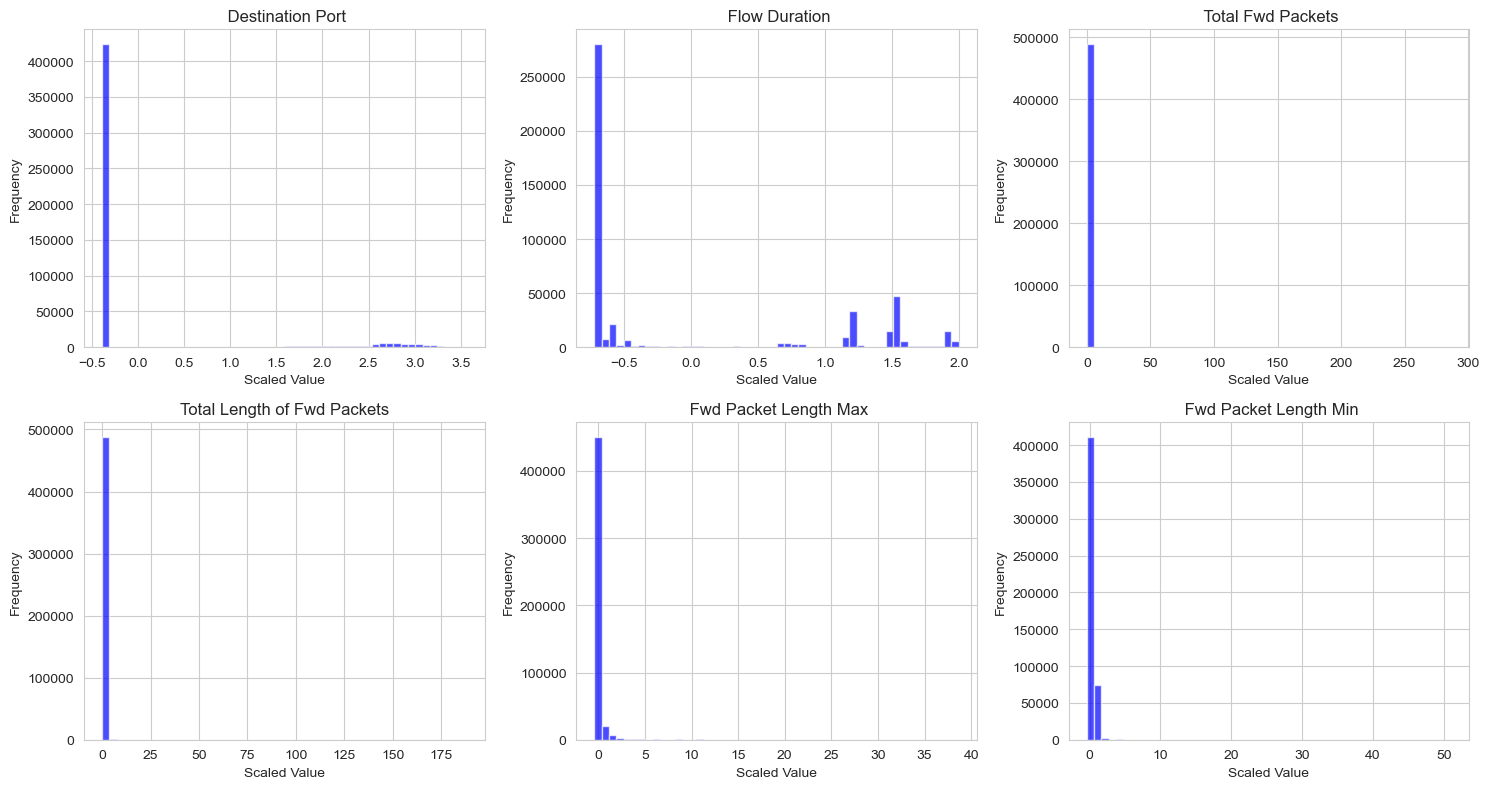

✓ Saved class distribution plot


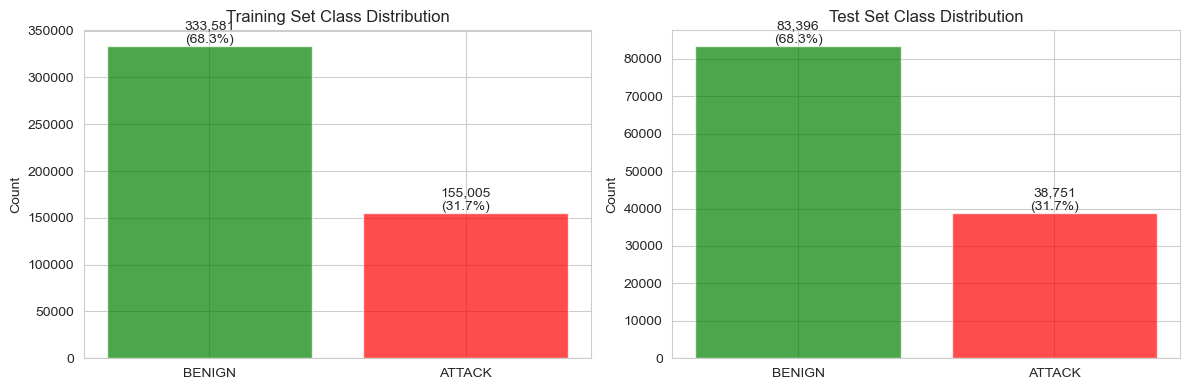


✅ Day 2 Complete!
Next: Day 3 - Train baseline classifier


In [29]:
print("\n" + "="*60)
print("VISUALIZATIONS")
print("="*60)

# Plot 1: Feature distributions (sample of 6 features)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, col in enumerate(feature_names[:6]):
    axes[idx].hist(X_train_scaled[col], bins=50, alpha=0.7, color='blue')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Scaled Value')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../results/figures/feature_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Saved feature distributions plot")
plt.show()

# Plot 2: Class balance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Training set
train_counts = pd.Series(y_train).value_counts()
ax1.bar(['BENIGN', 'ATTACK'], train_counts.values, color=['green', 'red'], alpha=0.7)
ax1.set_title('Training Set Class Distribution')
ax1.set_ylabel('Count')
for i, v in enumerate(train_counts.values):
    ax1.text(i, v, f'{v:,}\n({v/len(y_train)*100:.1f}%)', ha='center', va='bottom')

# Test set
test_counts = pd.Series(y_test).value_counts()
ax2.bar(['BENIGN', 'ATTACK'], test_counts.values, color=['green', 'red'], alpha=0.7)
ax2.set_title('Test Set Class Distribution')
ax2.set_ylabel('Count')
for i, v in enumerate(test_counts.values):
    ax2.text(i, v, f'{v:,}\n({v/len(y_test)*100:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved class distribution plot")
plt.show()

print("\n✅ Day 2 Complete!")
print("="*60)
print("Next: Day 3 - Train baseline classifier")


In [30]:
# ============================================
# DEBUG CELL: Check CICIDS2017 Label Format
# ============================================

import pandas as pd

# Load raw CICIDS data
# Adjust path to match your downloaded file
raw_files = [
    '../data/raw/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    '../data/raw/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    '../data/raw/Friday-WorkingHours-Morning.pcap_ISCX.csv',
    '../data/raw/Monday-WorkingHours.pcap_ISCX.csv',
    '../data/raw/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    '../data/raw/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    '../data/raw/Tuesday-WorkingHours.pcap_ISCX.csv',
    '../data/raw/Wednesday-workingHours.pcap_ISCX.csv',
]

# Try to load any available file
df_raw = None
for file_path in raw_files:
    try:
        df_raw = pd.read_csv(file_path)
        print(f"✓ Loaded: {file_path.split('/')[-1]}")
        break
    except:
        continue

if df_raw is None:
    print("❌ Could not load any CICIDS file")
    print("Checking what files you have:")
    import os
    if os.path.exists('../data/raw'):
        files = os.listdir('../data/raw')
        print("Files in data/raw/:")
        for f in files:
            print(f"  - {f}")
else:
    # Find label column (CICIDS uses ' Label' with a space)
    print("\nColumn names:")
    for col in df_raw.columns:
        if 'label' in col.lower():
            print(f"  Found label column: '{col}'")
    
    label_col = ' Label'  # CICIDS has a space before Label
    
    print("\n" + "="*60)
    print("CICIDS2017 LABEL DISTRIBUTION")
    print("="*60)
    
    print(f"\nTotal unique labels: {df_raw[label_col].nunique()}")
    print("\nAll labels with counts:")
    print(df_raw[label_col].value_counts())
    
    print("\n" + "="*60)
    print("SAMPLE LABELS (first 10):")
    print("="*60)
    
    for idx, label in enumerate(df_raw[label_col].unique()[:10], 1):
        label_str = str(label).strip().upper()
        
        print(f"\n{idx}. Original: '{label}'")
        print(f"   Stripped: '{label_str}'")
        print(f"   Length: {len(label_str)}")
        print(f"   Is 'BENIGN': {label_str == 'BENIGN'}")
        print(f"   Contains 'BENIGN': {'BENIGN' in label_str}")

✓ Loaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

Column names:
  Found label column: ' Label'

CICIDS2017 LABEL DISTRIBUTION

Total unique labels: 2

All labels with counts:
 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

SAMPLE LABELS (first 10):

1. Original: 'BENIGN'
   Stripped: 'BENIGN'
   Length: 6
   Is 'BENIGN': True
   Contains 'BENIGN': True

2. Original: 'DDoS'
   Stripped: 'DDOS'
   Length: 4
   Is 'BENIGN': False
   Contains 'BENIGN': False
